In [2]:
path_to_plots = '/home/sasi/Projects/SubgridCGMModel/plotting_for_paper/workshop_plots'

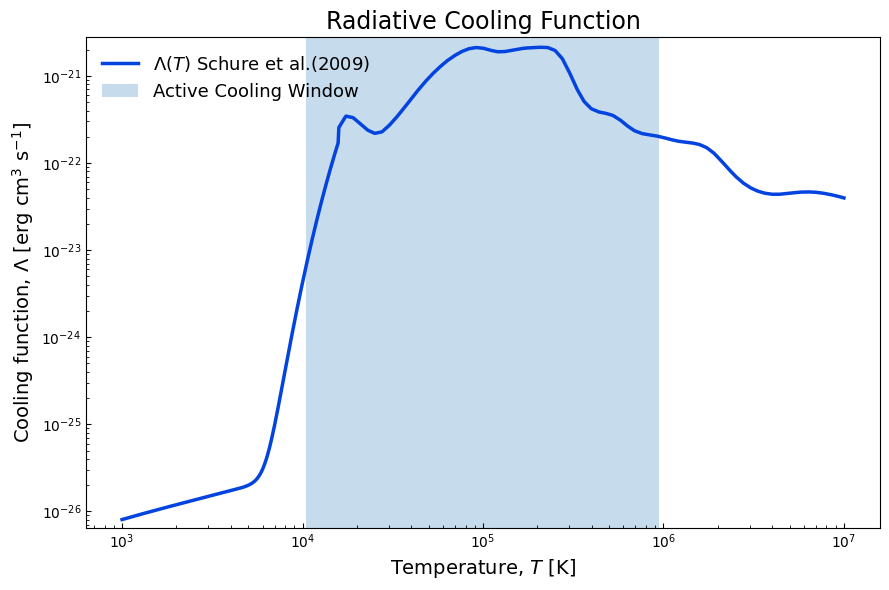

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import logging

# Suppress matplotlib missing font warnings
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ------------------------------------------------------------
# Your lambda_cool() function goes here
# ------------------------------------------------------------
def lambda_cool(temp, mask=False):
    """
    Cooling function ISMCoolFn translated from AthenaK C++.
    Works on scalars or numpy arrays (any shape).
    Returns Lambda(T) in erg cm^3 / s.
    """
    temp_arr = np.asarray(temp, dtype=float)
    scalar_input = temp_arr.ndim == 0

    # Make it safe for boolean indexing
    t = np.atleast_1d(temp_arr)

    logt = np.log10(t)

    lhd = np.array([
        -22.5977,
        -21.9689,
        -21.5972,
        -21.4615,
        -21.4789,
        -21.5497,
        -21.6211,
        -21.6595,
        -21.6426,
        -21.5688,
        -21.4771,
        -21.3755,
        -21.2693,
        -21.1644,
        -21.0658,
        -20.9778,
        -20.8986,
        -20.8281,
        -20.7700,
        -20.7223,
        -20.6888,
        -20.6739,
        -20.6815,
        -20.7051,
        -20.7229,
        -20.7208,
        -20.7058,
        -20.6896,
        -20.6797,
        -20.6749,
        -20.6709,
        -20.6748,
        -20.7089,
        -20.8031,
        -20.9647,
        -21.1482,
        -21.2932,
        -21.3767,
        -21.4129,
        -21.4291,
        -21.4538,
        -21.5055,
        -21.5740,
        -21.6300,
        -21.6615,
        -21.6766,
        -21.6886,
        -21.7073,
        -21.7304,
        -21.7491,
        -21.7607,
        -21.7701,
        -21.7877,
        -21.8243,
        -21.8875,
        -21.9738,
        -22.0671,
        -22.1537,
        -22.2265,
        -22.2821,
        -22.3213,
        -22.3462,
        -22.3587,
        -22.3590,
        -22.3512,
        -22.3420,
        -22.3342,
        -22.3312,
        -22.3346,
        -22.3445,
        -22.3595,
        -22.3780,
        -22.4007,
        -22.4289,
        -22.4625,
        -22.4995,
        -22.5353,
        -22.5659,
        -22.5895,
        -22.6059,
        -22.6161,
        -22.6208,
        -22.6213,
        -22.6184,
        -22.6126,
        -22.6045,
        -22.5945,
        -22.5831,
        -22.5707,
        -22.5573,
        -22.5434,
        -22.5287,
        -22.5140,
        -22.4992,
        -22.4844,
        -22.4695,
        -22.4543,
        -22.4392,
        -22.4237,
        -22.4087,
        -22.3928,
    ])

    lam = np.zeros_like(t, dtype=float)

    # KI02 regime
    mask_ki = logt <= 4.2
    if np.any(mask_ki):
        t_ki = t[mask_ki]
        lam[mask_ki] = (
            2.0e-19 * np.exp(-1.184e5 / (t_ki + 1.0e3))
            + 2.8e-28 * np.sqrt(t_ki) * np.exp(-92.0 / t_ki)
        )

    # CGOLS fit
    mask_hi = logt > 8.15
    if np.any(mask_hi):
        lam[mask_hi] = 10.0 ** (
            0.45 * logt[mask_hi] - 26.065
        )

    # SPEX interpolation
    mask_mid = (logt > 4.2) & (logt <= 8.15)
    if np.any(mask_mid):
        ipps = (25.0 * logt[mask_mid] - 103).astype(int)
        ipps = np.clip(ipps, 0, 100)

        x0 = 4.12 + 0.04 * ipps
        dx = logt[mask_mid] - x0

        logcool = (
            lhd[ipps + 1] * dx
            - lhd[ipps] * (dx - 0.04)
        ) * 25.0

        lam[mask_mid] = 10.0 ** logcool

    # Optional masking
    if mask:
        mask_extremes = (logt > np.log10(0.95e6)) | (logt < np.log10(1.05e4))
        lam[mask_extremes] = 0.0

    # Return a scalar if the input was scalar
    if scalar_input:
        return lam[0]

    # Otherwise preserve the original shape
    return lam.reshape(temp_arr.shape)

# Temperature range: 10^3 K -> 10^7 K
T = np.logspace(3, 7, 1000)

# Evaluate cooling function
Lambda = lambda_cool(T)

# ------------------------------------------------------------
# XKCD-style plot
# ------------------------------------------------------------


fig, ax = plt.subplots(figsize=(9, 6))

# 1. Force the plot area background to be solid white
#ax.set_facecolor('white')
#ax.patch.set_alpha(1.0) 

# 2. Move both major and minor ticks inside the plot area
ax.tick_params(axis='both', which='both', direction='in')

ax.loglog(
    T,
    Lambda,
    color="xkcd:blue",
    linewidth=2.5,
    label=r"$\Lambda(T)$ Schure et al.(2009)"
)

ax.axvspan(1.05e4, 0.95e6, alpha=0.25, label='Active Cooling Window')

ax.set_xlabel(r"Temperature, $T$ [K]", fontsize=14)
ax.set_ylabel(
    r"Cooling function, $\Lambda$ [erg cm$^3$ s$^{-1}$]",
    fontsize=14
)

ax.set_title(
    r"Radiative Cooling Function",
    fontsize=17
)

# Temperature limits
#ax.set_xlim(10**4.5, 10**5.5)

# Let matplotlib choose the y range
ax.set_ylim(
    Lambda[Lambda > 0].min() * 0.8,
    Lambda.max() * 1.3
)

# Grid
# ax.grid(
#     True,
#     which="both",
#     alpha=0.25,
#     linestyle="-"
# )

ax.legend(
    frameon=False,
    fontsize=13
)

plt.tight_layout()
file_savepath = path_to_plots + "/cooling_curve.png"
plt.savefig(file_savepath, transparent=True)
plt.show()

Average of Split Field:  2502500.0000
Average of Random Field: 2502500.0000


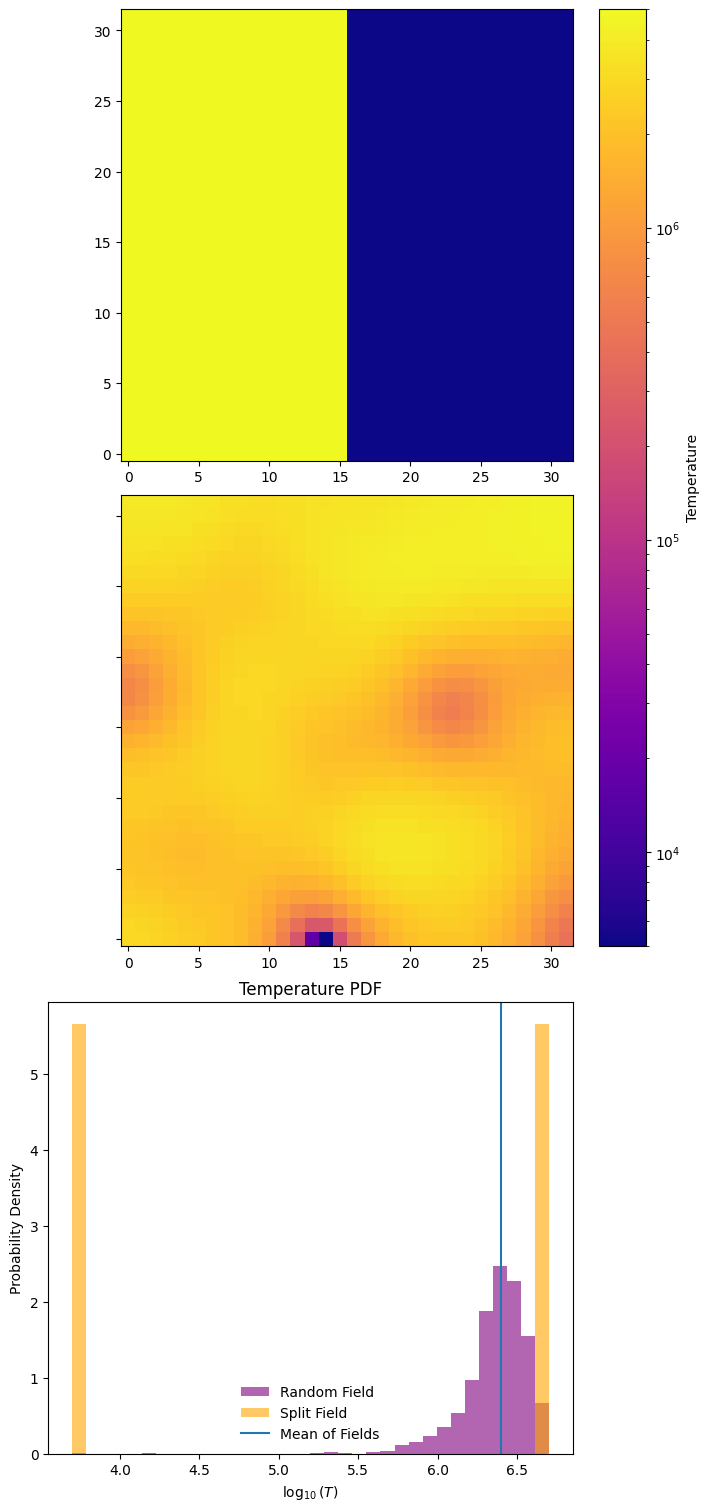

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

# ------------------------------------------------------------
# 1. Setup Parameters
# ------------------------------------------------------------
grid_size = 32
t_hot = 5e6
t_cold = 5e3

# The target average is exactly halfway between hot and cold
target_avg = (t_hot + t_cold) / 2.0

# ------------------------------------------------------------
# 2. Create Field 1: Clean Split
# ------------------------------------------------------------
field_split = np.zeros((grid_size, grid_size))
field_split[:, :grid_size//2] = t_hot
field_split[:, grid_size//2:] = t_cold

# ------------------------------------------------------------
# 3. Create Field 2: Continuous Random Field
# ------------------------------------------------------------
np.random.seed(42) 
noise = np.random.randn(grid_size, grid_size)
smoothed = gaussian_filter(noise, sigma=3.5)

# Normalize the smoothed noise to sit exactly between 0.0 and 1.0
s_min = np.min(smoothed)
s_max = np.max(smoothed)
U = (smoothed - s_min) / (s_max - s_min)

# Set the absolute floor of our temperature field to t_cold
base_temp = t_cold

# Calculate the exact multiplier needed to hit our target average
multiplier = (target_avg - base_temp) / np.mean(U)

# Generate the final field
field_random = (multiplier * U) + base_temp

print(f"Average of Split Field:  {np.mean(field_split):.4f}")
print(f"Average of Random Field: {np.mean(field_random):.4f}")
# ------------------------------------------------------------
# 4. Plotting (Fixed Layout)
# ------------------------------------------------------------
# ADDED: layout='constrained' handles complex colorbar spacing perfectly

fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(7, 15), layout='constrained')
cmap = 'plasma'

# Find global min and max for shared color scale and PDF bins
vmin = min(field_split.min(), field_random.min())
vmax = max(field_split.max(), field_random.max())
shared_norm = LogNorm(vmin=vmin, vmax=vmax)

# Manually share Y-axis between the first two plots
ax2.sharey(ax1)
ax2.tick_params(labelleft=False)

# Plot 1: Split Field
im1 = ax1.imshow(
    field_split, 
    cmap=cmap, 
    origin='lower', 
    norm=shared_norm
)
#ax1.set_title("Clean Split")
#ax1.set_ylabel("Y coordinate")

# Plot 2: Random Field
im2 = ax2.imshow(
    field_random, 
    cmap=cmap, 
    origin='lower', 
    norm=shared_norm
)
#ax2.set_title("Continuous Random")

#for ax in [ax1, ax2]:
#    ax.set_xlabel("X coordinate")

# FIXED: Removed manual fraction and pad limits. Let the constrained layout handle it!
fig.colorbar(im1, ax=[ax1, ax2], label="Temperature")

# ------------------------------------------------------------
# 5. Plot 3: Probability Density Function (PDF)
# ------------------------------------------------------------
log_split = np.log10(field_split.flatten())
log_random = np.log10(field_random.flatten())

# Create shared bins in log space for a clean comparison
bins = np.linspace(np.log10(vmin), np.log10(vmax), 35)

ax3.hist(
    log_random, 
    bins=bins, 
    density=True, 
    alpha=0.6, 
    color='purple', 
    label='Random Field'
)
ax3.hist(
    log_split, 
    bins=bins, 
    density=True, 
    alpha=0.6, 
    color='orange', 
    label='Split Field'
)
ax3.axvline(np.log10(target_avg), label='Mean of Fields')

ax3.set_title("Temperature PDF")
ax3.set_xlabel(r"$\log_{10}(T)$")
ax3.set_ylabel("Probability Density")
ax3.legend(frameon=False)

# FIXED: Removed plt.tight_layout() here because we used layout='constrained' above
file_savepath = path_to_plots + "/pdf_of_mock_fields.png"
plt.savefig(file_savepath, transparent=True)
plt.show()

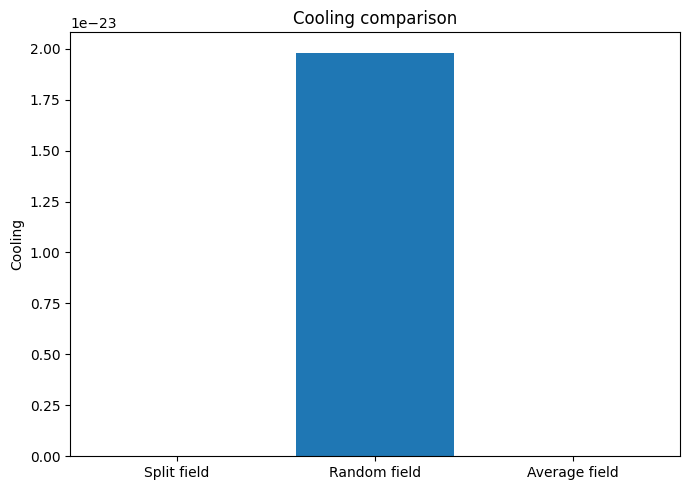

In [34]:
cooling_split_field = lambda_cool(field_split, mask=True).sum() / grid_size**2
cooling_random_field = lambda_cool(field_random, mask=True).sum() / grid_size**2
cooling_avg_field = lambda_cool(target_avg, mask=True) 

values = [
    cooling_split_field,
    cooling_random_field,
    cooling_avg_field,
]

labels = [
    "Split field",
    "Random field",
    "Average field",
]

plt.figure(figsize=(7, 5))
plt.bar(labels, values)

plt.ylabel("Cooling")
plt.title("Cooling comparison")
plt.tight_layout()
file_savepath = path_to_plots + "/comparision_histogram.png"
plt.savefig(file_savepath, transparent=True)
plt.show()


In [35]:
print(lambda_cool(1e3, mask=True))
print(lambda_cool(1e3, mask=False))

0.0
8.076123266766737e-27
